In [5]:
import pandas as pd
import re
import os

merged_sample = pd.read_csv("spotify_merged.csv")


In [7]:
merged_sample.head()

,title,rank,date,artist,url,region,chart,trend,streams,track_id,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,Chantaje (feat. Maluma),1,2017-01-01,Shakira,https://open.spotify.com/track/6mICuAdrwEjh6Y6...,Argentina,top200,SAME_POSITION,253019.0,6mICuAdrwEjh6Y6lroV2Kg,...,8.0,-2.921,0.0,0.0776,0.18700,0.000030,0.159,0.907,102.034,195840.0
1,Vente Pa' Ca (feat. Maluma),2,2017-01-01,Ricky Martin,https://open.spotify.com/track/7DM4BPaS7uofFul...,Argentina,top200,MOVE_UP,223988.0,7DM4BPaS7uofFul3ywMe46,...,11.0,-4.070,0.0,0.2260,0.00431,0.000017,0.101,0.533,99.935,259196.0
2,Reggaetón Lento (Bailemos),3,2017-01-01,CNCO,https://open.spotify.com/track/3AEZUABDXNtecAO...,Argentina,top200,MOVE_DOWN,210943.0,3AEZUABDXNtecAOSC1qTfo,...,4.0,-3.073,0.0,0.0502,0.40000,0.000000,0.176,0.710,93.974,222560.0
3,Safari,4,2017-01-01,"J Balvin, Pharrell Williams, BIA, Sky",https://open.spotify.com/track/6rQSrBHf7HlZjtc...,Argentina,top200,SAME_POSITION,173865.0,6rQSrBHf7HlZjtcMZ4S4bO,...,0.0,-4.361,1.0,0.3260,0.55100,0.000003,0.126,0.555,180.044,205600.0
4,Shaky Shaky,5,2017-01-01,Daddy Yankee,https://open.spotify.com/track/58IL315gMSTD37D...,Argentina,top200,MOVE_UP,153956.0,58IL315gMSTD37DOZPJ2hf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
merged_sample.loc[4,'url']


'https://open.spotify.com/track/58IL315gMSTD37DOZPJ2hf'

In [10]:
merged_sample.columns




Index(['title', 'rank', 'date', 'artist', 'url', 'region', 'chart', 'trend',
       'streams', 'track_id', 'track_name', 'track_artist', 'track_popularity',
       'playlist_genre', 'playlist_subgenre', 'danceability', 'energy', 'key',
       'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness',
       'liveness', 'valence', 'tempo', 'duration_ms'],
      dtype='object')

In [14]:
print(merged_sample.loc[0,'track_popularity'])

76.0


In [19]:

nan_dataset = merged_sample[merged_sample["track_name"].isna()].copy()



In [20]:
nan_dataset.head()



,title,rank,date,artist,url,region,chart,trend,streams,track_id,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
4,Shaky Shaky,5,2017-01-01,Daddy Yankee,https://open.spotify.com/track/58IL315gMSTD37D...,Argentina,top200,MOVE_UP,153956.0,58IL315gMSTD37DOZPJ2hf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Cuando Se Pone a Bailar,7,2017-01-01,Rombai,https://open.spotify.com/track/1MpKZi1zTXpERKw...,Argentina,top200,MOVE_DOWN,148369.0,1MpKZi1zTXpERKwxmOu1PH,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10,Andas En Mi Cabeza,11,2017-01-01,"Chino & Nacho, Daddy Yankee",https://open.spotify.com/track/5mey7CLLuFToM2P...,Argentina,top200,SAME_POSITION,110395.0,5mey7CLLuFToM2P68Qu1gF,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
13,Gyal You A Party Animal - Remix,14,2017-01-01,"Charly Black, Daddy Yankee",https://open.spotify.com/track/1AkTW13ysu0AJrw...,Argentina,top200,MOVE_DOWN,99722.0,1AkTW13ysu0AJrwuM6UY0I,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,La Bicicleta (feat. Maluma) - Remix,16,2017-01-01,"Carlos Vives, Shakira",https://open.spotify.com/track/7IRuf7FrdQvOGs0...,Argentina,top200,MOVE_UP,92723.0,7IRuf7FrdQvOGs0g9mSNGr,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [35]:
nan_dataset.shape

nan_dataset.loc[399, 'date']


'2017-01-01'

In [44]:
daty = nan_dataset['date'].unique()




In [ ]:
top5_per_month = (
    nan_dataset.sort_values(['rank']).head(5)                                
)

AttributeError: Can only use .dt accessor with datetimelike values

In [2]:
merged_check = pd.read_csv("spotify_merged.csv", usecols=["track_id", "track_name"])
print("Połączone rekordy:", merged_check["track_name"].notna().sum())
print("Wszystkie rekordy:", len(merged_check))
print("Procent połączenia:", round(100 * merged_check["track_name"].notna().mean(), 2), "%")

Połączone rekordy: 8705312
Wszystkie rekordy: 26173514
Procent połączenia: 33.26 %


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 20)

# 1. Analiza spotify_songs.csv

In [4]:
songs = pd.read_csv("spotify_songs.csv")

In [5]:
songs.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,playlist_subgenre,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,dance pop,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


Rozmiar i typy

In [6]:
print("Liczba wierszy i kolumn:", songs.shape)
songs.info()

Liczba wierszy i kolumn: (32833, 23)
<class 'pandas.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  str    
 1   track_name                32828 non-null  str    
 2   track_artist              32828 non-null  str    
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  str    
 5   track_album_name          32828 non-null  str    
 6   track_album_release_date  32833 non-null  str    
 7   playlist_name             32833 non-null  str    
 8   playlist_id               32833 non-null  str    
 9   playlist_genre            32833 non-null  str    
 10  playlist_subgenre         32833 non-null  str    
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non

Braki danych

In [7]:
missing_songs = songs.isna().sum()
missing_songs[missing_songs > 0].sort_values(ascending=False)

track_name          5
track_artist        5
track_album_name    5
dtype: int64

Usunięcie rekordów z brakami danych

In [8]:
songs_clean = songs.dropna(subset=["track_name", "track_artist", "track_album_name"])

In [9]:
print("Przed czyszczeniem:", len(songs))
print("Po czyszczeniu:", len(songs_clean))
print("Usunięto:", len(songs) - len(songs_clean))

Przed czyszczeniem: 32833
Po czyszczeniu: 32828
Usunięto: 5


Duplikaty

In [10]:
print("Duplikaty całych wierszy:", songs_clean.duplicated().sum())
print("Duplikaty po track_id:", songs_clean.duplicated(subset=["track_id"]).sum())

Duplikaty całych wierszy: 0
Duplikaty po track_id: 4476


Statystyki opisowe

In [11]:
songs_clean.describe()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
count,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000,32828.000000
mean,42.483551,0.654850,0.698603,5.373949,-6.719529,0.565737,0.107053,0.175352,0.084760,0.190175,0.510556,120.883642,225796.829779
std,24.980476,0.145092,0.180916,3.611572,2.988641,0.495667,0.101307,0.219644,0.224245,0.154313,0.233152,26.903632,59836.492346
min,0.000000,0.000000,0.000175,0.000000,-46.448000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4000.000000
25%,24.000000,0.563000,0.581000,2.000000,-8.171250,0.000000,0.041000,0.015100,0.000000,0.092700,0.331000,99.961000,187804.500000
50%,45.000000,0.672000,0.721000,6.000000,-6.166000,1.000000,0.062500,0.080400,0.000016,0.127000,0.512000,121.984000,216000.000000
75%,62.000000,0.761000,0.840000,9.000000,-4.645000,1.000000,0.132000,0.255000,0.004830,0.248000,0.693000,133.918250,253581.250000
max,100.000000,0.983000,1.000000,11.000000,1.275000,1.000000,0.918000,0.994000,0.994000,0.996000,0.991000,239.440000,517810.000000


Histogramy

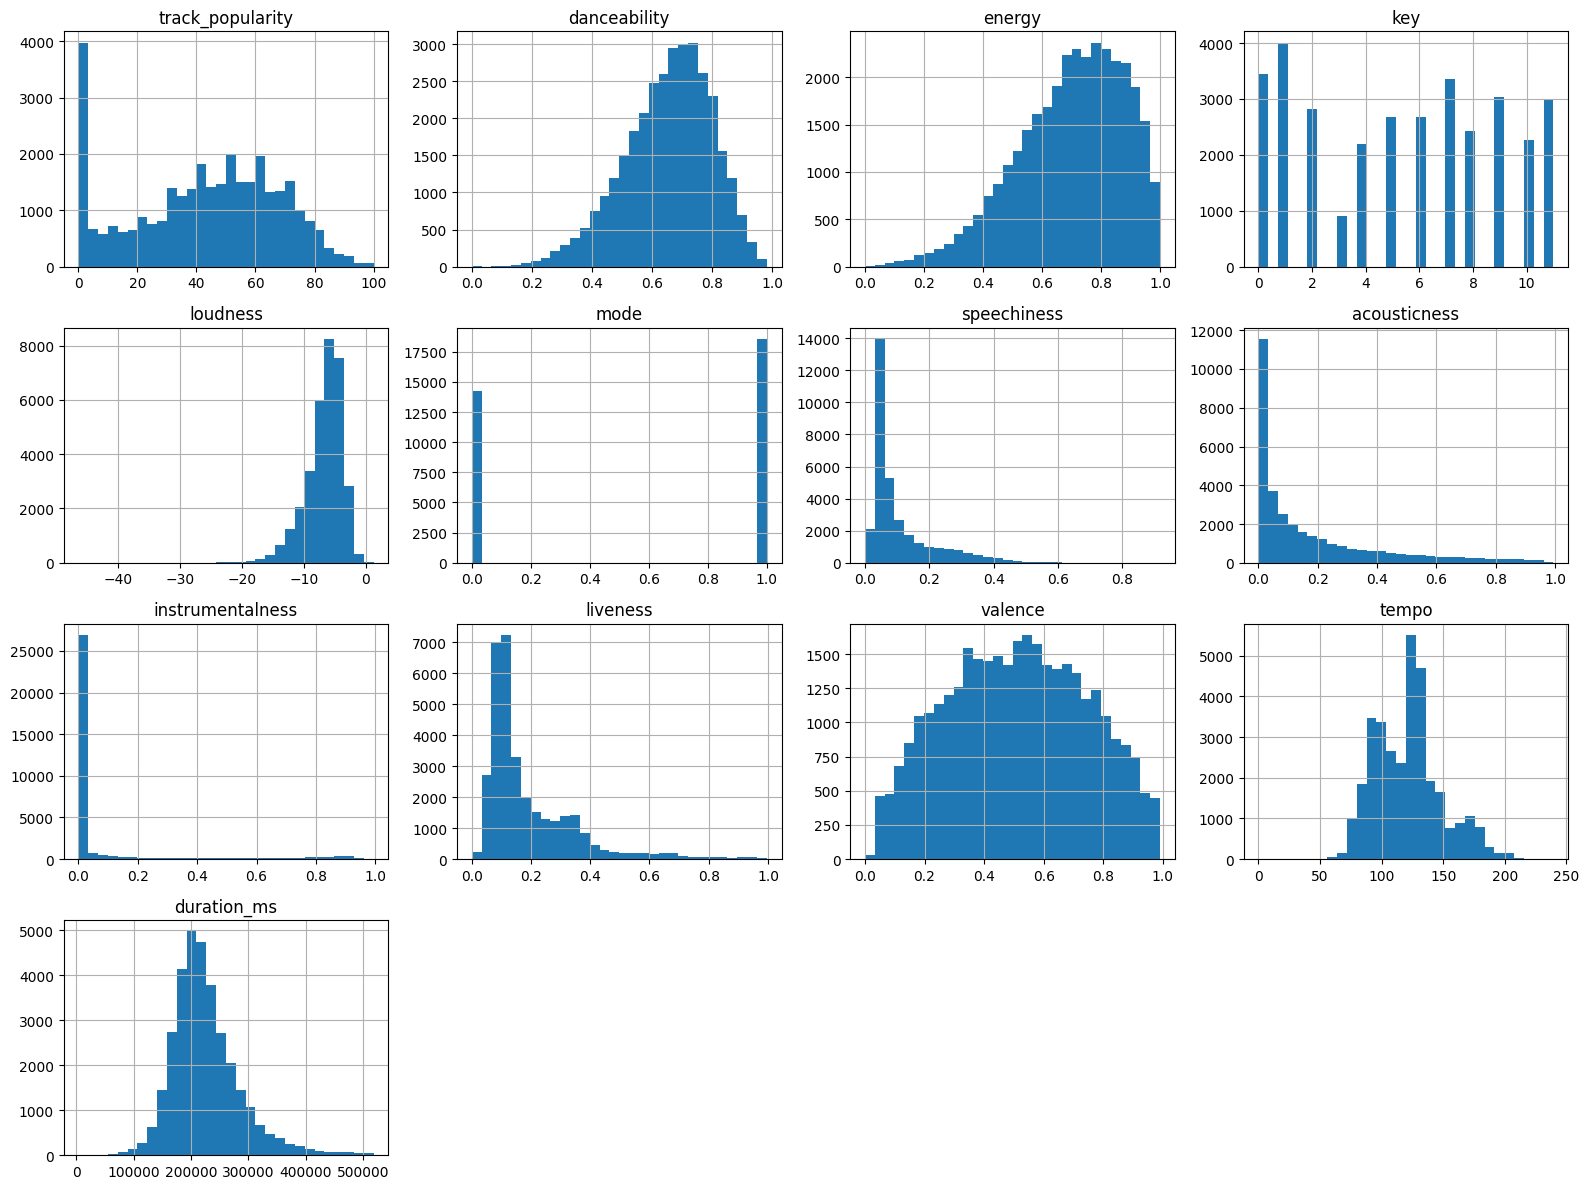

In [12]:
num_cols_songs = [
    "track_popularity", "danceability", "energy", "key", "loudness",
    "mode", "speechiness", "acousticness", "instrumentalness",
    "liveness", "valence", "tempo", "duration_ms"
]

songs_clean[num_cols_songs].hist(figsize=(16, 12), bins=30)
plt.tight_layout()
plt.show()

Boxploty wybranych zmiennych

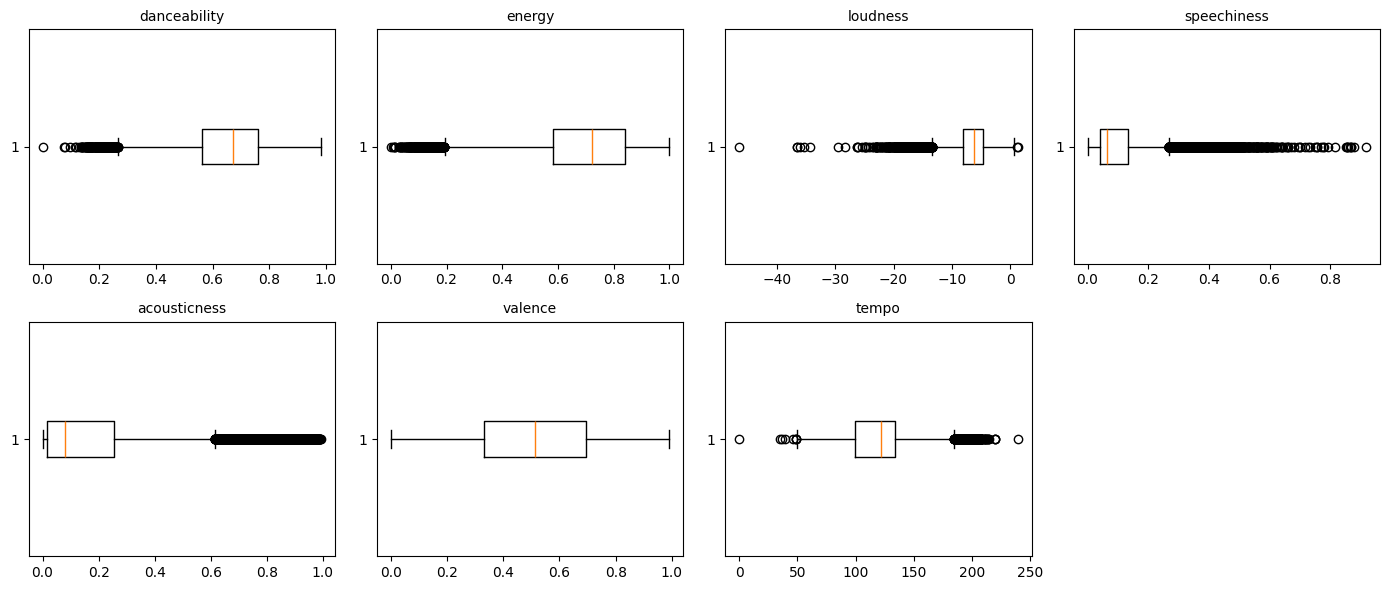

In [13]:
cols_box = ["danceability", "energy", "loudness", "speechiness", "acousticness", "valence", "tempo"]

fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(14, 6))
axes = axes.flatten()

for i, col in enumerate(cols_box):
    axes[i].boxplot(songs_clean[col].dropna(), vert=False)
    axes[i].set_title(col, fontsize=10)

# ukrycie pustego ostatniego pola
for j in range(len(cols_box), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Najczęstsze gatunki

In [14]:
songs_clean["playlist_genre"].value_counts()

playlist_genre
edm      6043
rap      5743
pop      5507
r&b      5431
latin    5153
rock     4951
Name: count, dtype: int64

Liczba unikalnych wartości

In [15]:
songs_clean.nunique().sort_values(ascending=False)

track_id             28352
track_name           23449
track_album_id       22543
duration_ms          19782
track_album_name     19743
                     ...  
track_popularity       101
playlist_subgenre       24
key                     12
playlist_genre           6
mode                     2
Length: 23, dtype: int64

# 2. Analiza spotify_charts.csv

Wczytanie próbki

In [16]:
charts = pd.read_csv(
    "spotify_charts.csv",
    usecols=["title", "rank", "date", "artist", "url", "region", "chart", "trend", "streams"]
)

charts_sample = charts.sample(n=300000, random_state=42)

In [17]:
charts_sample.head()

,title,rank,date,artist,url,region,chart,trend,streams
8642892,Wallah,145,2019-11-20,"DIVINE, Shah Rule",https://open.spotify.com/track/0d4PvVcC2GxJoVm...,India,top200,MOVE_DOWN,19389.0
1748190,Reggaetón Lento (Bailemos),91,2018-02-26,CNCO,https://open.spotify.com/track/3AEZUABDXNtecAO...,Bolivia,top200,MOVE_UP,1433.0
25539930,Raindrops On A Leaf - Live Uit Liefde Voor Muziek,41,2017-05-09,Lady Linn,https://open.spotify.com/track/3fE1ka0B7q5EN2P...,Belgium,viral50,NEW_ENTRY,NaN
11767591,Happier,54,2017-05-16,Ed Sheeran,https://open.spotify.com/track/2RttW7RAu5nOAfq...,Australia,top200,MOVE_UP,49757.0
2140579,Roll in Peace (feat. XXXTENTACION),173,2018-07-01,Kodak Black,https://open.spotify.com/track/40oKW22ZNNkEdZL...,Canada,top200,MOVE_UP,24745.0


In [18]:
print("Liczba wierszy i kolumn:", charts_sample.shape)

Liczba wierszy i kolumn: (300000, 9)


In [19]:
charts_sample.info()

<class 'pandas.DataFrame'>
Index: 300000 entries, 8642892 to 25864060
Data columns (total 9 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   title    299999 non-null  str    
 1   rank     300000 non-null  int64  
 2   date     300000 non-null  str    
 3   artist   300000 non-null  str    
 4   url      300000 non-null  str    
 5   region   300000 non-null  str    
 6   chart    300000 non-null  str    
 7   trend    300000 non-null  str    
 8   streams  232593 non-null  float64
dtypes: float64(1), int64(1), str(7)
memory usage: 22.9 MB


Zamiana kolumny date na typ daty

In [20]:
charts_sample["date"] = pd.to_datetime(charts_sample["date"], errors="coerce")

Braki danych

In [21]:
missing_charts = charts_sample.isna().sum()
missing_charts[missing_charts > 0].sort_values(ascending=False)

streams    67407
title          1
dtype: int64

Usunięcie rekordów z brakującym tytułem

In [22]:

charts_sample_clean = charts_sample.dropna(subset=["title"])

Duplikaty całych wierszy

In [23]:
print("Duplikaty całych wierszy:", charts_sample_clean.duplicated().sum())

Duplikaty całych wierszy: 0


Duplikaty po najważniejszych kolumnach

In [24]:
print(
    "Duplikaty po title, artist, date, region:",
    charts_sample_clean.duplicated(subset=["title", "artist", "date", "region"]).sum()
)

Duplikaty po title, artist, date, region: 292


Statystyki opisowe dla kolumn numerycznych

In [25]:
charts_sample_clean.describe()

,rank,date,streams
count,299999.000000,299999,2.325930e+05
mean,80.803253,2019-08-20 23:07:02.773409,5.423316e+04
min,1.000000,2017-01-01 00:00:00,1.001000e+03
25%,29.000000,2018-06-14 00:00:00,3.552000e+03
50%,67.000000,2019-09-20 00:00:00,9.577000e+03
75%,131.000000,2020-11-11 00:00:00,3.524700e+04
max,200.000000,2021-12-31 00:00:00,9.657593e+06
std,59.213987,NaN,2.018283e+05


Liczba unikalnych wartosci

In [26]:
charts_sample_clean.nunique().sort_values(ascending=False)

streams    77966
url        51696
title      43344
artist     26994
date        1826
rank         200
region        70
trend          4
chart          2
dtype: int64

Zakres dat

In [27]:
print("Najwcześniejsza data:", charts_sample_clean["date"].min())
print("Najpóźniejsza data:", charts_sample_clean["date"].max())

Najwcześniejsza data: 2017-01-01 00:00:00
Najpóźniejsza data: 2021-12-31 00:00:00


Histogramy

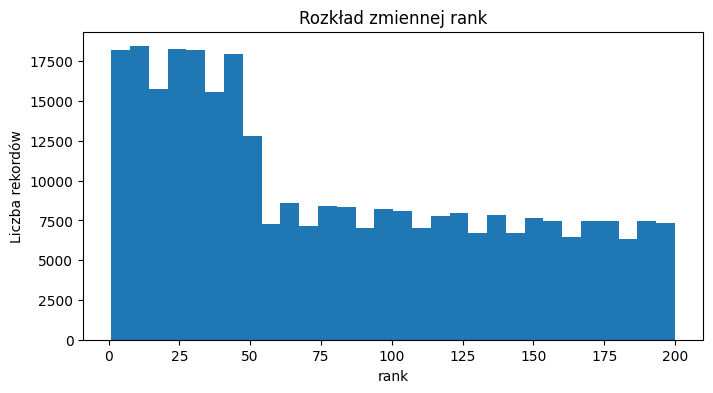

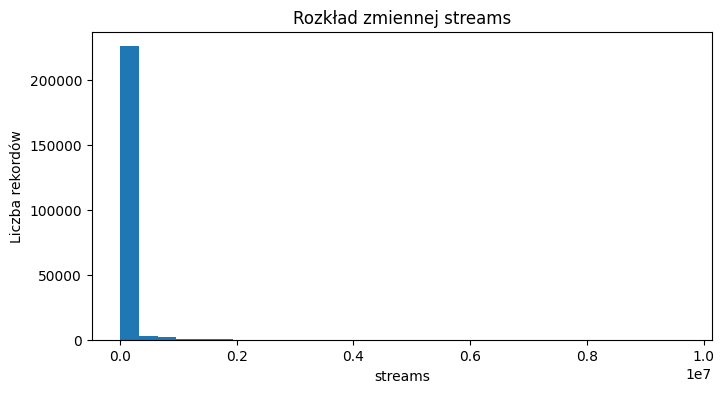

In [28]:
plt.figure(figsize=(8, 4))
plt.hist(charts_sample_clean["rank"].dropna(), bins=30)
plt.title("Rozkład zmiennej rank")
plt.xlabel("rank")
plt.ylabel("Liczba rekordów")
plt.show()

plt.figure(figsize=(8, 4))
plt.hist(charts_sample_clean["streams"].dropna(), bins=30)
plt.title("Rozkład zmiennej streams")
plt.xlabel("streams")
plt.ylabel("Liczba rekordów")
plt.show()

Liczba rekordów według daty

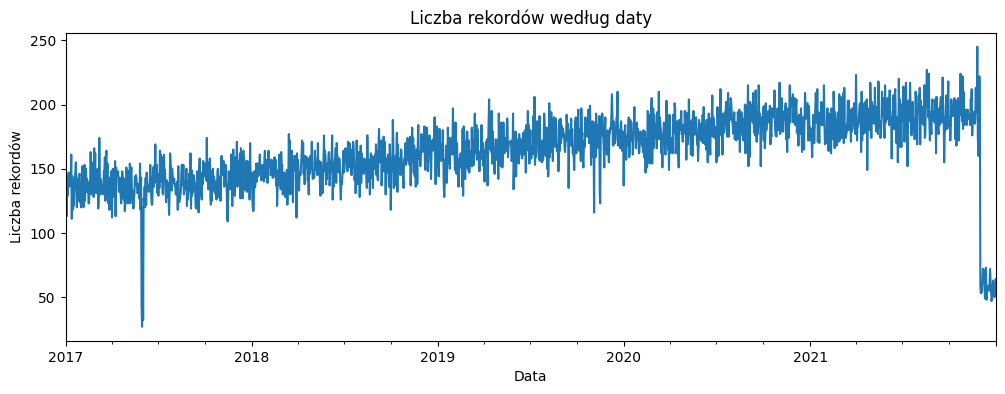

In [29]:
charts_sample_clean["date"].value_counts().sort_index().plot(figsize=(12, 4))
plt.title("Liczba rekordów według daty")
plt.xlabel("Data")
plt.ylabel("Liczba rekordów")
plt.show()